In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


## Simulaatio

In [4]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [5]:
def find_params(q,A,evolution,f_rabi,AC_stark, lims, scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]

    f_d = q.frequency/3 #Ajotaajuus
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = pulses.sim_3_part_pulses(f_d+delta,f_ef,A,evolution,dim,f_rabi,t_ramp=5,U_f=1)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_d-ω_q/3 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

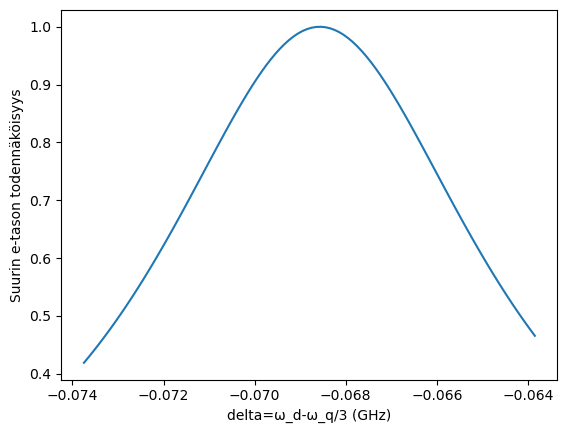

Amplitudi (GHz): 5.862378319584177
AC-stark siirtymä (GHz): -0.06854670085959402
E-tason suurin todennäköisyys: 0.9999722735360224
Pulssin pituus (ns): 242.60967656360634
Rabi-taajuus (fourier):  0.001997862955250715


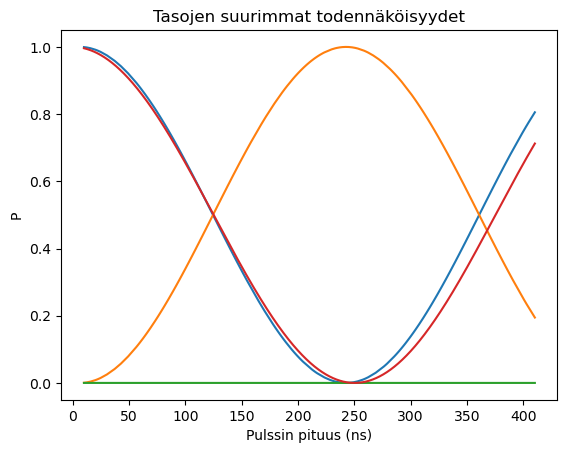

---------------------------------------------


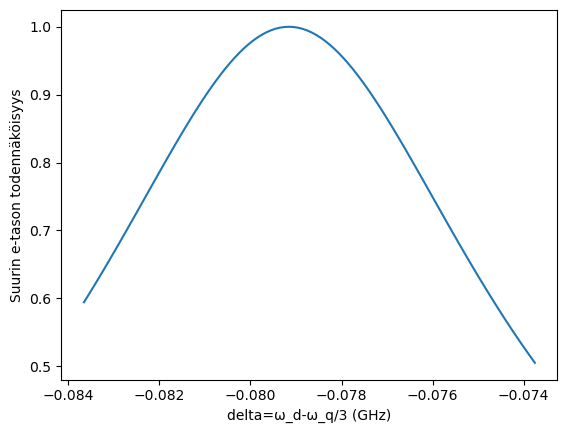

Amplitudi (GHz): 6.291660027196749
AC-stark siirtymä (GHz): -0.07915537484610222
E-tason suurin todennäköisyys: 0.9999968703801957
Pulssin pituus (ns): 197.36735939440845
Rabi-taajuus (fourier):  0.002622292145850022


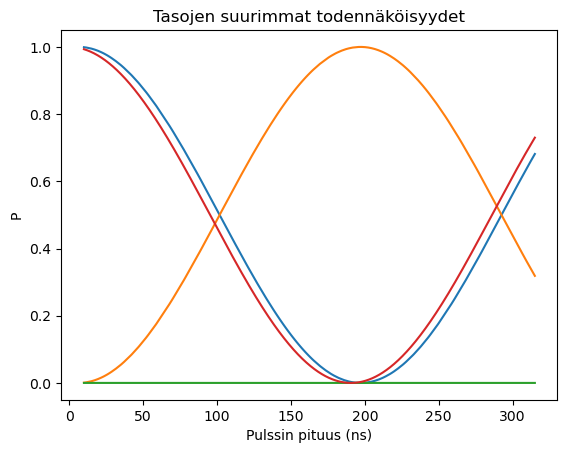

---------------------------------------------


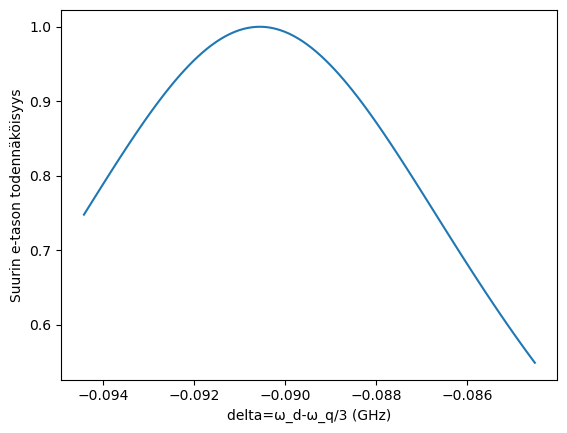

Amplitudi (GHz): 6.720941734809321
AC-stark siirtymä (GHz): -0.09052059521492348
E-tason suurin todennäköisyys: 0.9999625110813022
Pulssin pituus (ns): 162.48853427690116
Rabi-taajuus (fourier):  0.0033004730651181907


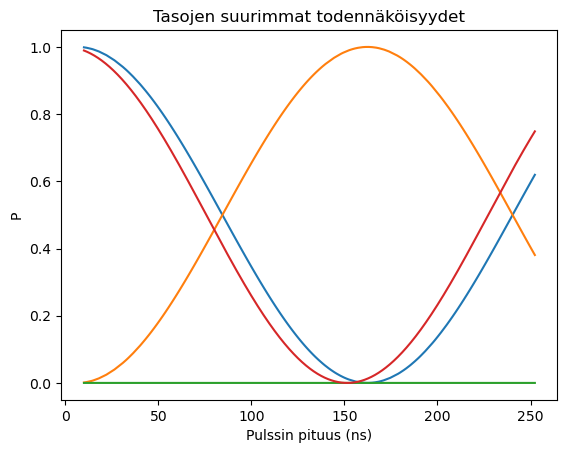

---------------------------------------------


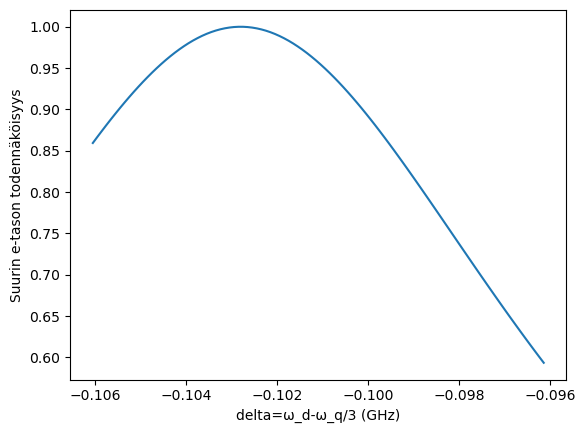

Amplitudi (GHz): 7.1502234424218925
AC-stark siirtymä (GHz): -0.10284236196605781
E-tason suurin todennäköisyys: 0.9999641378400111
Pulssin pituus (ns): 135.7631473456766
Rabi-taajuus (fourier):  0.0040462508557145395


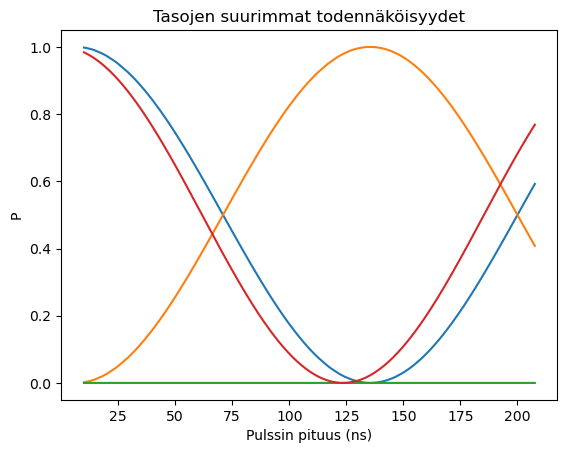

---------------------------------------------


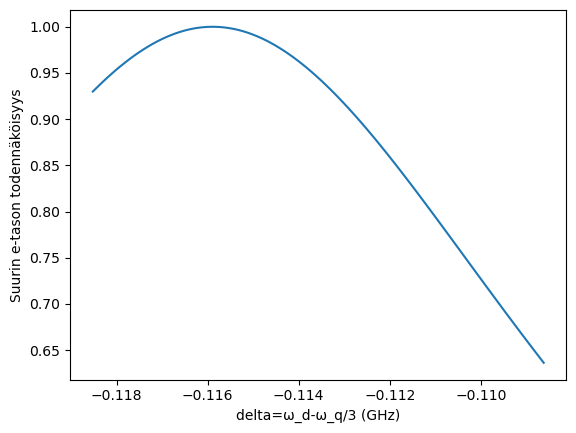

Amplitudi (GHz): 7.579505150034464
AC-stark siirtymä (GHz): -0.11592067509950522
E-tason suurin todennäköisyys: 0.9999845364778999
Pulssin pituus (ns): 114.21641995076162
Rabi-taajuus (fourier):  0.004873639948893703


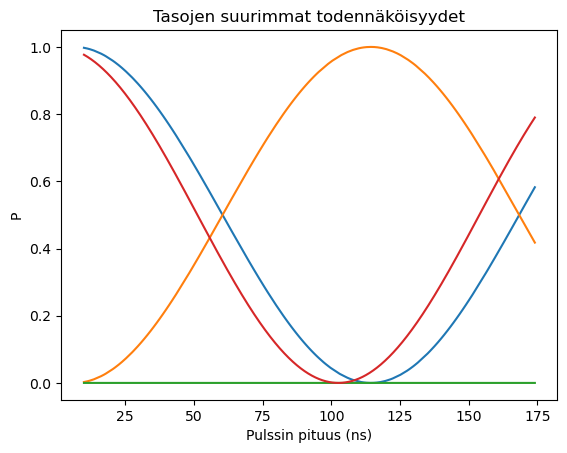

---------------------------------------------


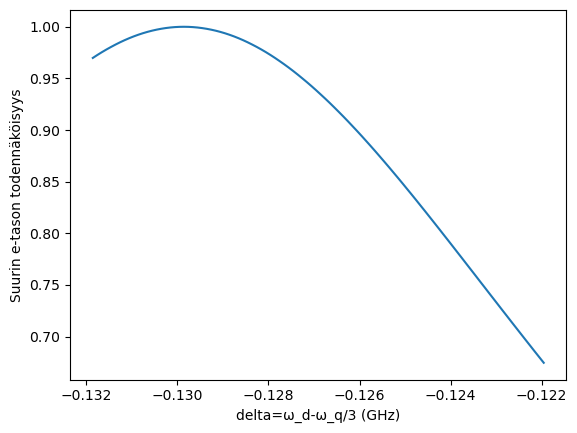

Amplitudi (GHz): 8.008786857647035
AC-stark siirtymä (GHz): -0.12985553461526572
E-tason suurin todennäköisyys: 0.9999943424541947
Pulssin pituus (ns): 97.86784279373498
Rabi-taajuus (fourier):  0.005796414750605155


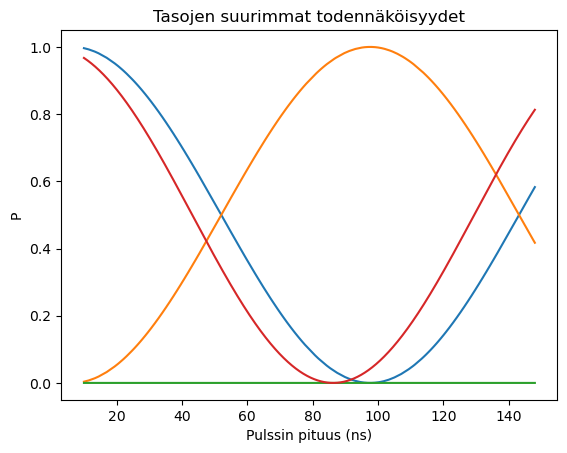

---------------------------------------------


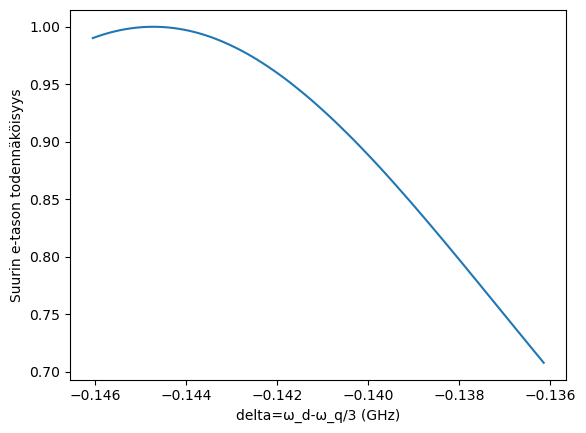

Amplitudi (GHz): 8.438068565259606
AC-stark siirtymä (GHz): -0.14474694051333922
E-tason suurin todennäköisyys: 0.9999804552327362
Pulssin pituus (ns): 83.72993915771177
Rabi-taajuus (fourier):  0.006828538968056969


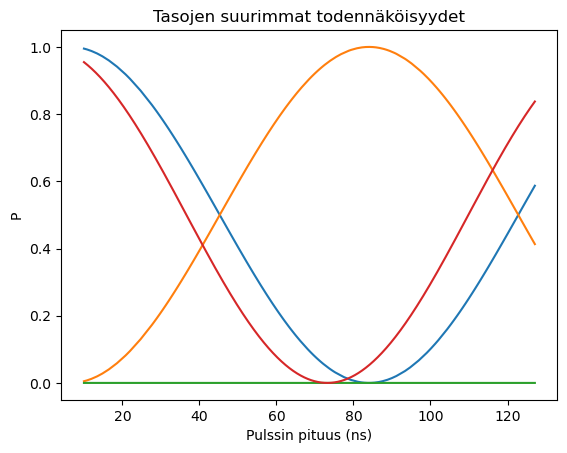

---------------------------------------------


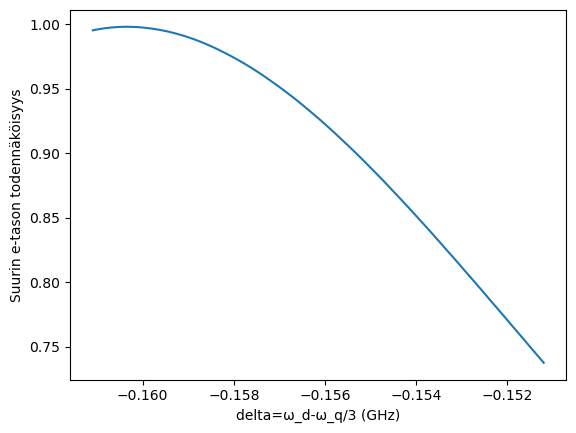

Amplitudi (GHz): 8.867350272872178
AC-stark siirtymä (GHz): -0.1603948927937259
E-tason suurin todennäköisyys: 0.997996666475207
Pulssin pituus (ns): 73.3157241189765
Rabi-taajuus (fourier):  0.007983960047708334


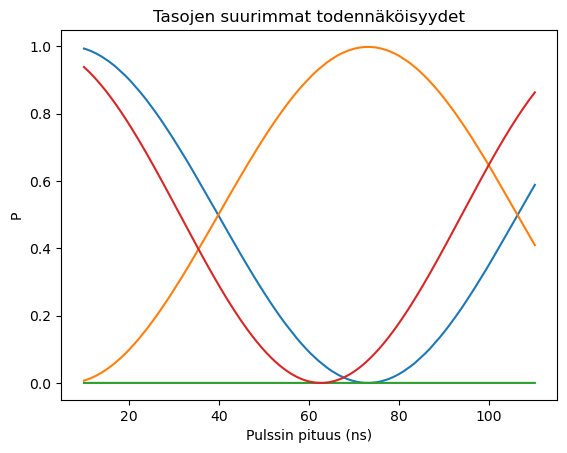

---------------------------------------------


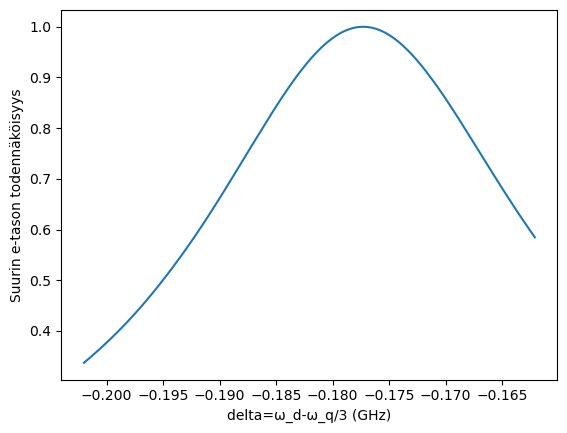

Amplitudi (GHz): 9.296631980484749
AC-stark siirtymä (GHz): -0.17729939145642556
E-tason suurin todennäköisyys: 0.9997776940403582
Pulssin pituus (ns): 63.625611479726594
Rabi-taajuus (fourier):  0.00927654038644214


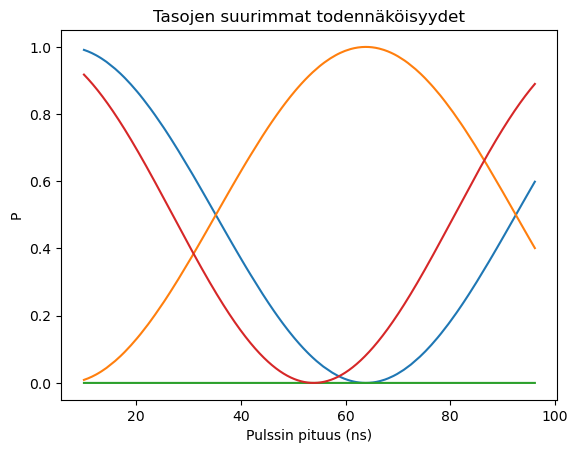

---------------------------------------------


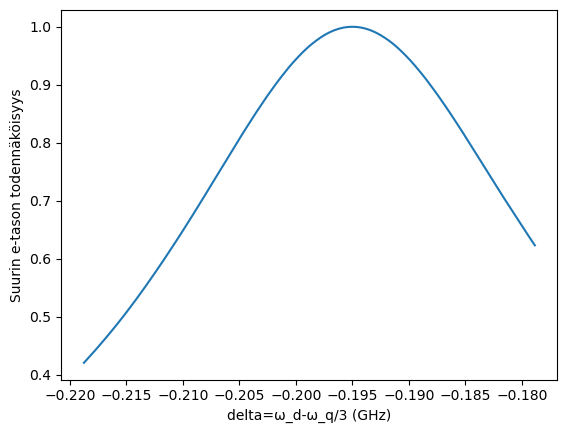

Amplitudi (GHz): 9.725913688097322
AC-stark siirtymä (GHz): -0.19496043650143846
E-tason suurin todennäköisyys: 0.9998797132315033
Pulssin pituus (ns): 56.17072901239535
Rabi-taajuus (fourier):  0.01072008425608494


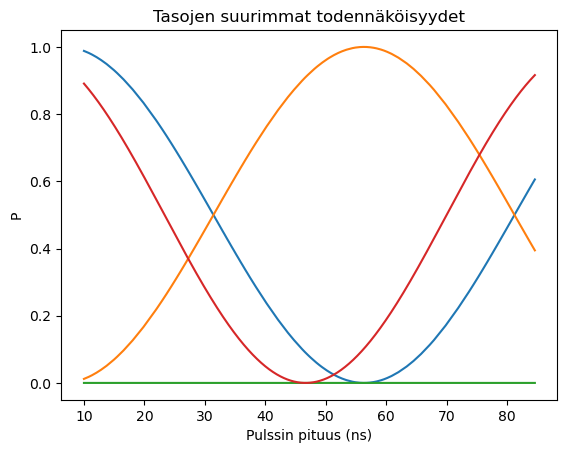

---------------------------------------------


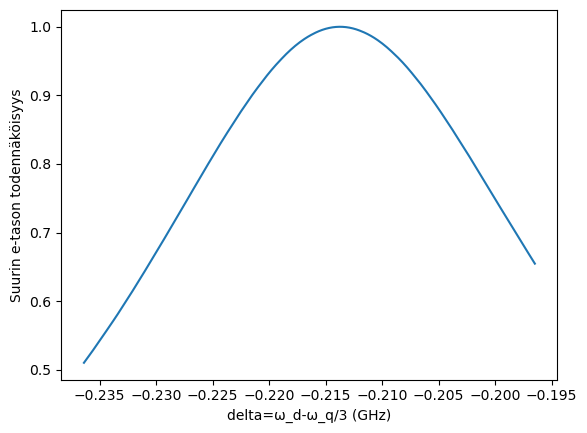

Amplitudi (GHz): 10.155195395709892
AC-stark siirtymä (GHz): -0.21367802792876428
E-tason suurin todennäköisyys: 0.9999028894800288
Pulssin pituus (ns): 50.20620817925993
Rabi-taajuus (fourier):  0.010787900517755529


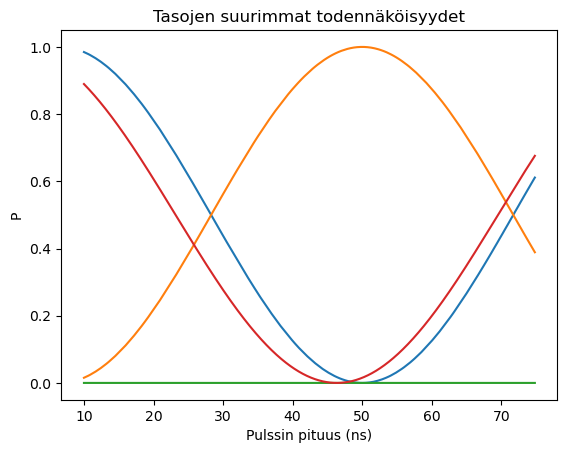

---------------------------------------------


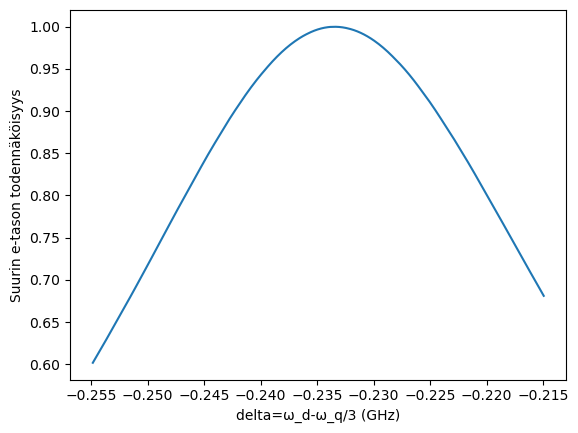

Amplitudi (GHz): 10.584477103322463
AC-stark siirtymä (GHz): -0.23345216573840316
E-tason suurin todennäköisyys: 0.9999310715133891
Pulssin pituus (ns): 44.979466120281145
Rabi-taajuus (fourier):  0.012352097477916971


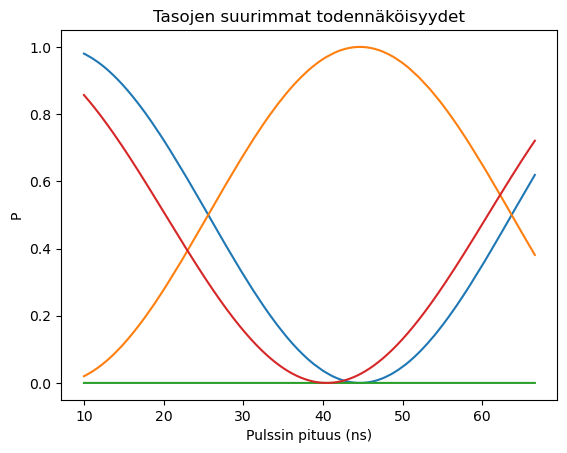

---------------------------------------------


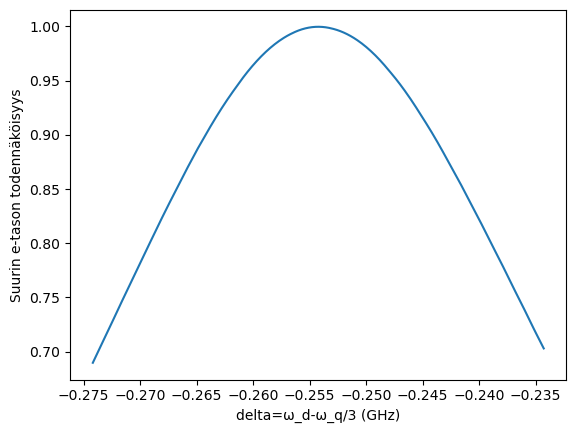

Amplitudi (GHz): 11.013758810935034
AC-stark siirtymä (GHz): -0.25428284993035516
E-tason suurin todennäköisyys: 0.9999474647176269
Pulssin pituus (ns): 40.493803029964084
Rabi-taajuus (fourier):  0.014084198943044336


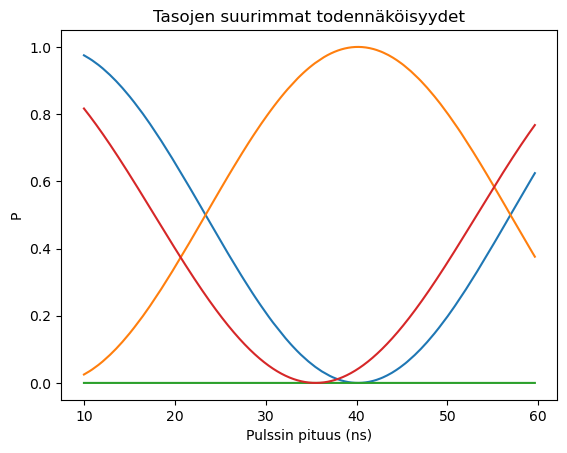

---------------------------------------------


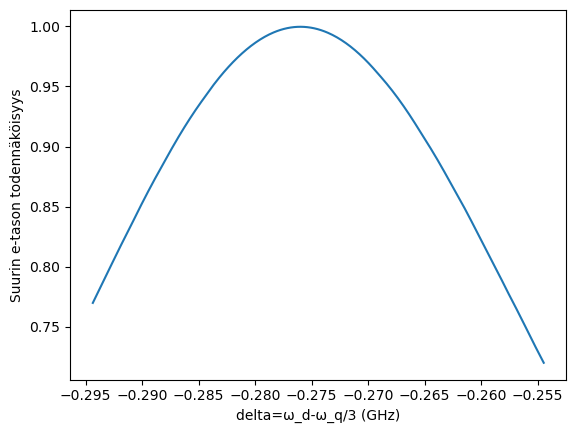

Amplitudi (GHz): 11.443040518547605
AC-stark siirtymä (GHz): -0.2759700805046203
E-tason suurin todennäköisyys: 0.999962356663061
Pulssin pituus (ns): 35.98811596506074
Rabi-taajuus (fourier):  0.015997959806590186


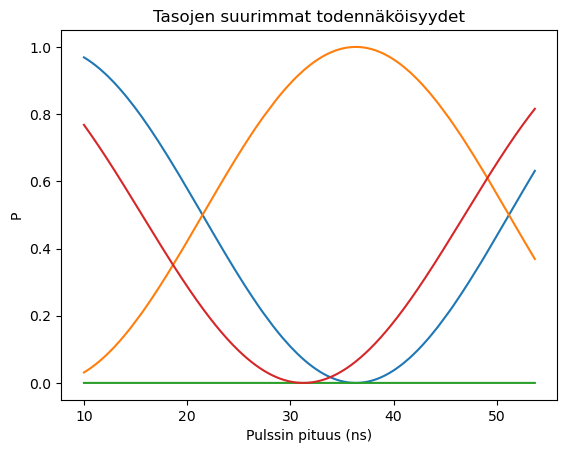

---------------------------------------------


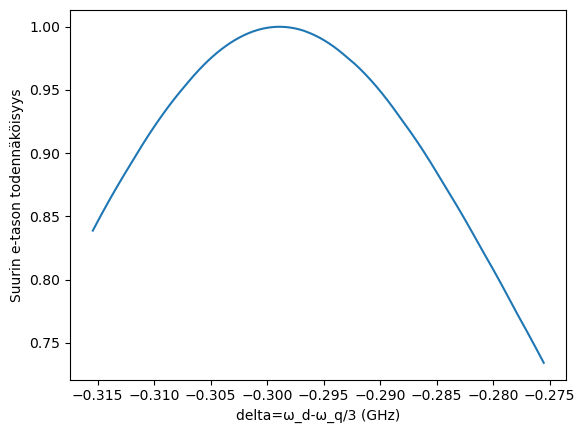

Amplitudi (GHz): 11.872322226160177
AC-stark siirtymä (GHz): -0.29891385746119853
E-tason suurin todennäköisyys: 0.9999638943470319
Pulssin pituus (ns): 32.99487236230321
Rabi-taajuus (fourier):  0.018103817588802865


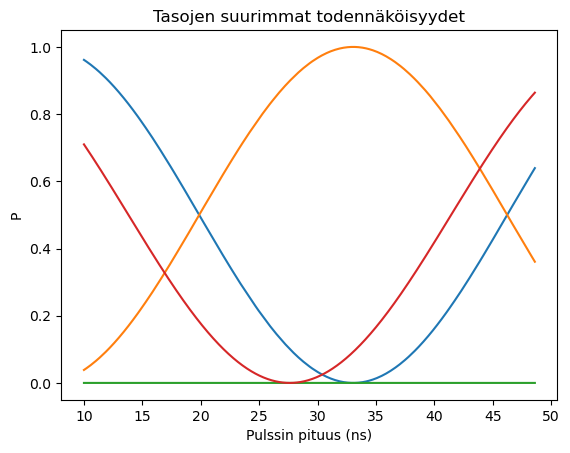

---------------------------------------------


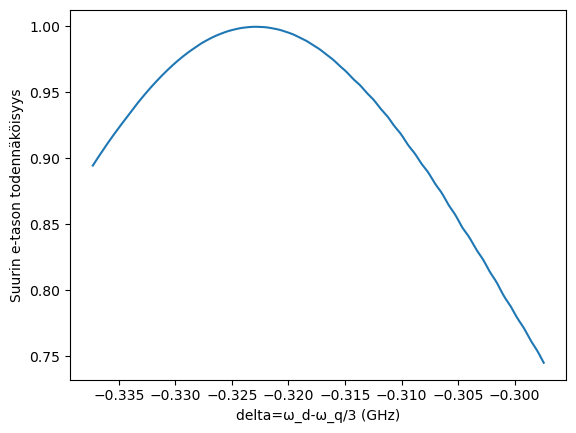

Amplitudi (GHz): 12.30160393377275
AC-stark siirtymä (GHz): -0.32291418080008977
E-tason suurin todennäköisyys: 0.9998760106304525
Pulssin pituus (ns): 29.987409267572033
Rabi-taajuus (fourier):  0.020416440340819575


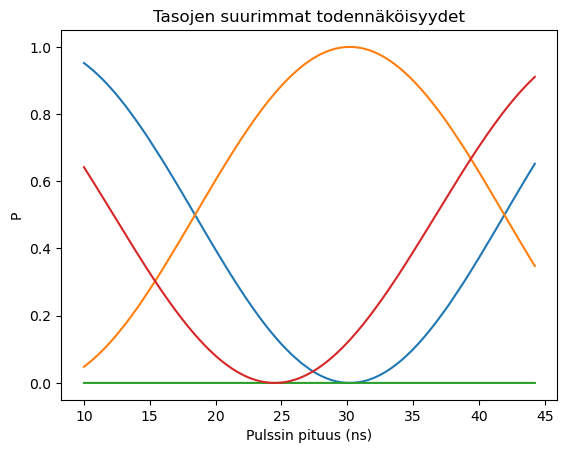

---------------------------------------------


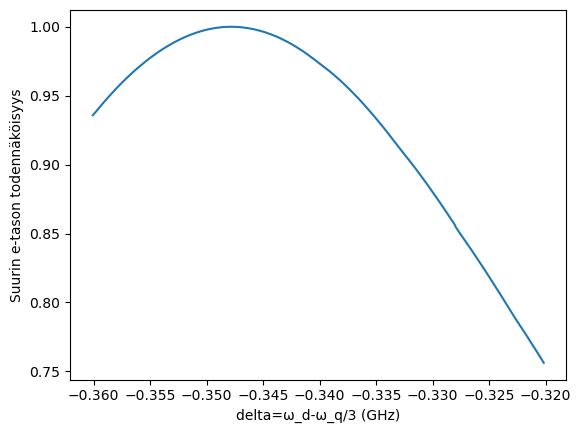

Amplitudi (GHz): 12.73088564138532
AC-stark siirtymä (GHz): -0.3477710505212941
E-tason suurin todennäköisyys: 0.9999361612794038
Pulssin pituus (ns): 27.73510633115194
Rabi-taajuus (fourier):  0.022944622105911725


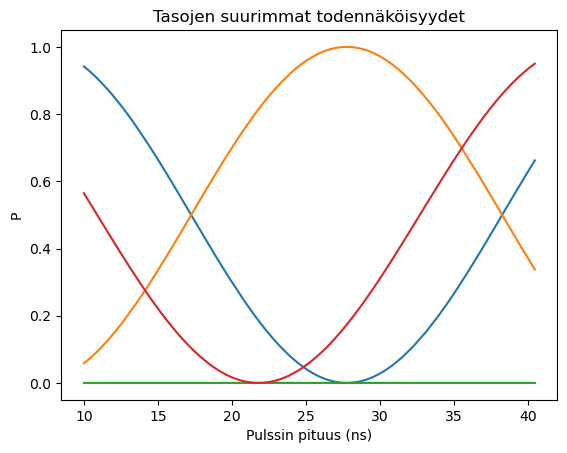

---------------------------------------------


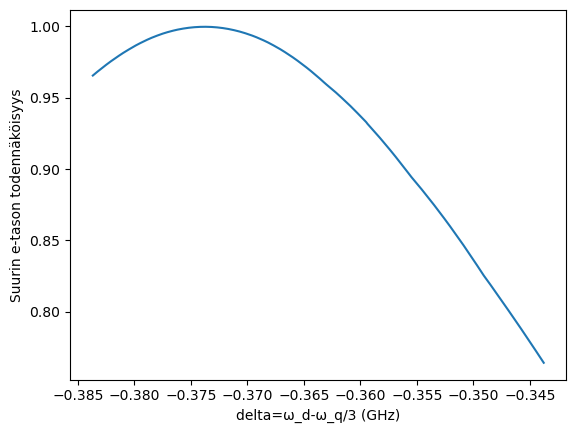

Amplitudi (GHz): 13.160167348997891
AC-stark siirtymä (GHz): -0.37378446662481146
E-tason suurin todennäköisyys: 0.9999203752141766
Pulssin pituus (ns): 25.471222626015695
Rabi-taajuus (fourier):  0.025703901689779252


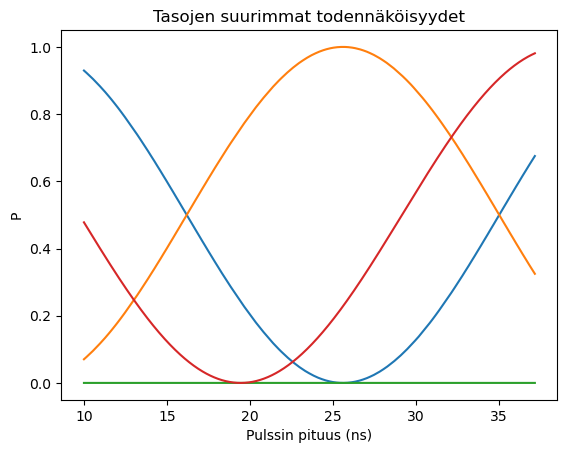

---------------------------------------------


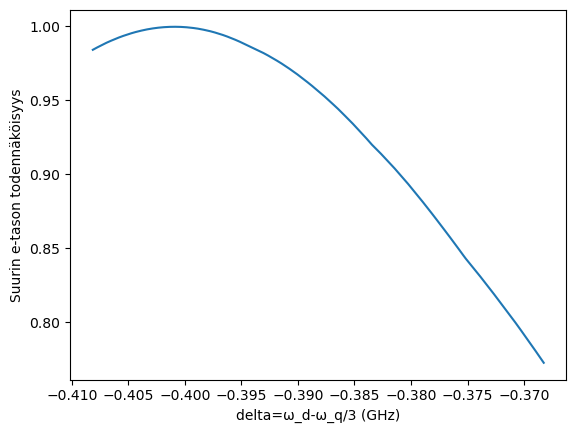

Amplitudi (GHz): 13.589449056610464
AC-stark siirtymä (GHz): -0.400954429110642
E-tason suurin todennäköisyys: 0.9998767955810162
Pulssin pituus (ns): 23.970833629201408
Rabi-taajuus (fourier):  0.028703975025634015


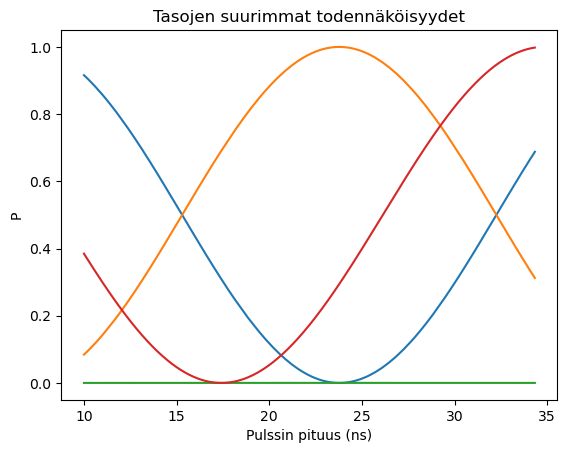

---------------------------------------------


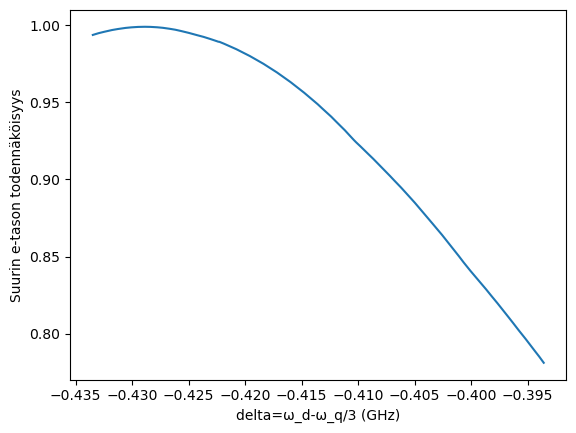

Amplitudi (GHz): 14.018730764223035
AC-stark siirtymä (GHz): -0.42888093797878557
E-tason suurin todennäköisyys: 0.9998276994582176
Pulssin pituus (ns): 22.46150776611851
Rabi-taajuus (fourier):  0.031956182967276904


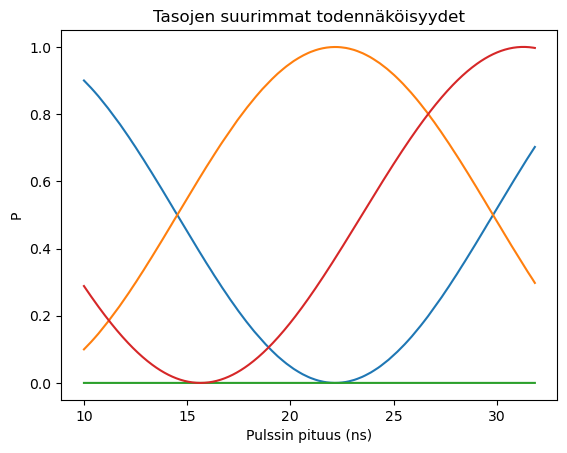

---------------------------------------------


In [6]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.23
max_range = 0.55
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
    AC_stark=-0.002324*A**2 + 0.005164 *A - 0.01915 #Arvaus AC-stark siirtymälle
    if i < 8:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi*8,AC_stark,[-50,50],10000)
    else:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi*8,AC_stark,[-300,100],10000)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    max_vals.append(params[2])
    data.append(params[3])
    
    f_d_opt = qubit.frequency/3+deltas[-1] #Löydetty optimaalinen ajotaajuus

    m=10
    vals = pulses.sim_3_part_pulses(f_d_opt,f_ef,A,evolution_eigenbasis,dim,(8*f_rabi)/m,t_ramp=5,U_f=0)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("F-tason suurin todennäköisyys:", vals[1])
    print("Verrokki:",params[2])

    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(5.862378319584177), np.float64(6.291660027196749), np.float64(6.720941734809321), np.float64(7.1502234424218925), np.float64(7.579505150034464), np.float64(8.008786857647035), np.float64(8.438068565259606), np.float64(8.867350272872178), np.float64(9.296631980484749), np.float64(9.725913688097322), np.float64(10.155195395709892), np.float64(10.584477103322463), np.float64(11.013758810935034), np.float64(11.443040518547605), np.float64(11.872322226160177), np.float64(12.30160393377275), np.float64(12.73088564138532), np.float64(13.160167348997891), np.float64(13.589449056610464), np.float64(14.018730764223035)]


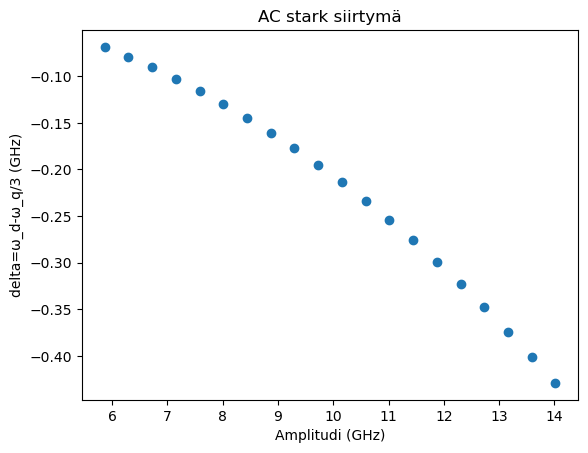

[np.float64(-0.06854670085959402), np.float64(-0.07915537484610222), np.float64(-0.09052059521492348), np.float64(-0.10284236196605781), np.float64(-0.11592067509950522), np.float64(-0.12985553461526572), np.float64(-0.14474694051333922), np.float64(-0.1603948927937259), np.float64(-0.17729939145642556), np.float64(-0.19496043650143846), np.float64(-0.21367802792876428), np.float64(-0.23345216573840316), np.float64(-0.25428284993035516), np.float64(-0.2759700805046203), np.float64(-0.29891385746119853), np.float64(-0.32291418080008977), np.float64(-0.3477710505212941), np.float64(-0.37378446662481146), np.float64(-0.400954429110642), np.float64(-0.42888093797878557)]


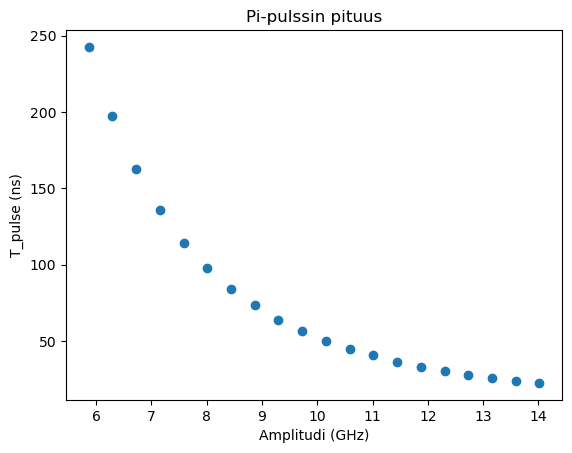

[np.float64(242.60967656360634), np.float64(197.36735939440845), np.float64(162.48853427690116), np.float64(135.7631473456766), np.float64(114.21641995076162), np.float64(97.86784279373498), np.float64(83.72993915771177), np.float64(73.3157241189765), np.float64(63.625611479726594), np.float64(56.17072901239535), np.float64(50.20620817925993), np.float64(44.979466120281145), np.float64(40.493803029964084), np.float64(35.98811596506074), np.float64(32.99487236230321), np.float64(29.987409267572033), np.float64(27.73510633115194), np.float64(25.471222626015695), np.float64(23.970833629201408), np.float64(22.46150776611851)]


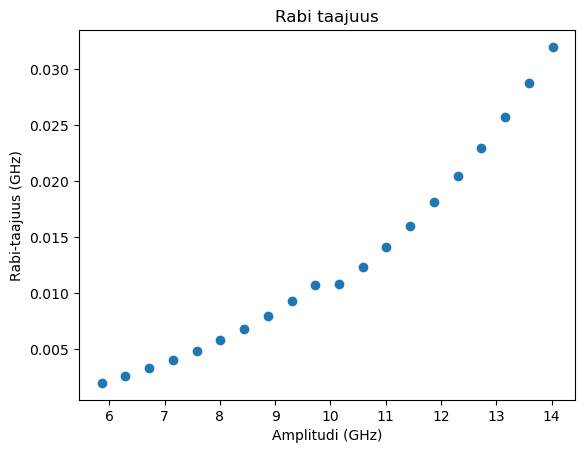

[np.float64(0.001997862955250715), np.float64(0.002622292145850022), np.float64(0.0033004730651181907), np.float64(0.0040462508557145395), np.float64(0.004873639948893703), np.float64(0.005796414750605155), np.float64(0.006828538968056969), np.float64(0.007983960047708334), np.float64(0.00927654038644214), np.float64(0.01072008425608494), np.float64(0.010787900517755529), np.float64(0.012352097477916971), np.float64(0.014084198943044336), np.float64(0.015997959806590186), np.float64(0.018103817588802865), np.float64(0.020416440340819575), np.float64(0.022944622105911725), np.float64(0.025703901689779252), np.float64(0.028703975025634015), np.float64(0.031956182967276904)]


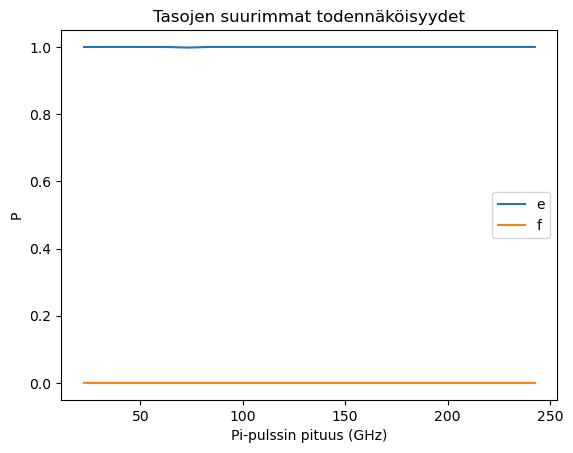

[np.float64(0.9999722735360224), np.float64(0.9999968703801957), np.float64(0.9999625110813022), np.float64(0.9999641378400111), np.float64(0.9999845364778999), np.float64(0.9999943424541947), np.float64(0.9999804552327362), np.float64(0.997996666475207), np.float64(0.9997776940403582), np.float64(0.9998797132315033), np.float64(0.9999028894800288), np.float64(0.9999310715133891), np.float64(0.9999474647176269), np.float64(0.999962356663061), np.float64(0.9999638943470319), np.float64(0.9998760106304525), np.float64(0.9999361612794038), np.float64(0.9999203752141766), np.float64(0.9998767955810162), np.float64(0.9998276994582176)]
[np.float64(8.658875868623661e-07), np.float64(1.0366738807151748e-06), np.float64(1.3586014940106776e-06), np.float64(1.6750966507953809e-06), np.float64(1.6540546256045482e-06), np.float64(1.8106428393372133e-06), np.float64(2.1970014237074187e-06), np.float64(3.235387853326872e-05), np.float64(1.7310357742788733e-06), np.float64(1.7733804598773794e-06), np

In [7]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.semilogy(pulse_lengths, e_vals)
plt.semilogy(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)